# Real-Time Financial Transaction Intelligence & Risk Platform
### Batch pipeline: ETL → dimensional warehouse → risk ML → natural-language analytics

An end-to-end data pipeline that ingests financial transactions, models them in a star-schema warehouse, scores each transaction for fraud risk with a machine-learning model, and lets you **ask questions in plain English** that are answered by LLM-generated SQL over validated data.

**Stack:** Python · pandas · **SQLite** (warehouse) · scikit-learn · Google Gemini · matplotlib

---

## What each stage demonstrates
| Stage | Skill it proves |
|---|---|
| Synthetic data + raw zone | Data ingestion, raw/curated separation |
| ETL + validation | Extract-transform-load, **data-quality gates** |
| Staging → intermediate | The **dbt layered transformation pattern** + data tests |
| Star schema | **Dimensional modelling** (facts & dimensions) |
| Feature engineering + ML | ML **integrated into a pipeline** (not a standalone notebook) |
| NL-to-SQL layer | **LLM + SQL + structured data** (not another chatbot) |
| Dashboard + health | BI output and **pipeline observability** |

## Pipeline flow

```
Synthetic sources ─▶ Raw zone (CSV) ─▶ ETL + validation ─▶ SQLite warehouse
                                                                │
                    staging ─▶ intermediate ─▶ star schema ◀────┘
                                                   │
                              feature engineering ─▶ Risk ML model ─▶ fct_risk_alerts
                                                   │
                    Natural-language question ─▶ LLM ─▶ SQL ─▶ (safety gate) ─▶ warehouse
                                                                                    │
                                                        validated results ─▶ LLM explanation
```


---
## Phase 1 — Setup


In [ ]:
!pip install faker scikit-learn pandas numpy matplotlib google-generativeai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import sqlite3                     # the warehouse (real SQL, zero setup)
import random, datetime as dt
from faker import Faker            # synthetic but realistic customer data
import google.generativeai as genai
import logging, time, re

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
fake = Faker(); Faker.seed(SEED)

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
logger = logging.getLogger("txn_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
logger.propagate = False
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler("pipeline.log"); _fh.setFormatter(_fmt); logger.addHandler(_fh)
_ch = logging.StreamHandler(); _ch.setFormatter(_fmt); logger.addHandler(_ch)
logger.info("Pipeline logging initialised")

2026-09-18 18:25:58,194 | INFO | Pipeline logging initialised


In [ ]:
from google.colab import userdata

# Reuse the same free Gemini key from the RAG project (Colab Secrets → GEMINI_API_KEY)
genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
gemini_model = genai.GenerativeModel('gemini-2.5-flash-lite')
print("\u2713 Gemini configured")

✓ Gemini configured


---
## Phase 2 — Data Generation & Raw Zone

In [ ]:
N_CUST, N_MERCH, N_TXN = 200, 40, 15000
HOME = ["US", "GB", "IN", "DE", "SG"]

# --- dimension source data ---
customers = pd.DataFrame({
    "customer_id":      [f"C{1000+i}" for i in range(N_CUST)],
    "name":             [fake.name() for _ in range(N_CUST)],
    "home_country":     np.random.choice(HOME, N_CUST),
    "account_age_days": np.random.randint(1, 2000, N_CUST),
})
merchants = pd.DataFrame({
    "merchant_id":       [f"M{200+i}" for i in range(N_MERCH)],
    "category":          np.random.choice(["grocery","electronics","travel","gaming","crypto","fashion"], N_MERCH),
    "merchant_risk_tier":np.random.choice([1, 2, 3], N_MERCH, p=[.6, .3, .1]),
})

# --- transactions, with bursts so 'velocity' is a real signal ---
cust_ids  = np.random.choice(customers["customer_id"], N_TXN)
merch_ids = np.random.choice(merchants["merchant_id"], N_TXN)
start = dt.datetime(2024, 1, 1)
cust_base = {c: np.random.randint(0, 60*24*90) for c in customers["customer_id"]}

timestamps = []
for c in cust_ids:
    if np.random.rand() < 0.6:                      # 60% cluster into short bursts
        offset = cust_base[c] + np.random.randint(0, 180)
    else:
        offset = cust_base[c] + np.random.randint(0, 60*24*60)
    timestamps.append(start + dt.timedelta(minutes=offset))

txn = pd.DataFrame({
    "transaction_id": [f"T{900000+i}" for i in range(N_TXN)],
    "customer_id":    cust_ids,
    "merchant_id":    merch_ids,
    "timestamp":      pd.to_datetime(timestamps),
    "amount":         np.round(np.random.exponential(80, N_TXN) + 1, 2),
    "txn_country":    np.random.choice(HOME + ["NG","RU","BR"], N_TXN,
                                       p=[.18,.18,.18,.18,.16,.04,.04,.04]),
    "channel":        np.random.choice(["web","mobile","pos"], N_TXN, p=[.4,.45,.15]),
    "status":         np.random.choice(["success","failed"], N_TXN, p=[.94,.06]),
})
txn = txn.merge(customers[["customer_id","home_country","account_age_days"]], on="customer_id")
txn = txn.merge(merchants[["merchant_id","merchant_risk_tier"]], on="merchant_id")

# --- inject a realistic (hidden) fraud pattern for the model to recover ---
txn = txn.sort_values(["customer_id","timestamp"]).reset_index(drop=True)
def _velocity(g):
    g = g.set_index("timestamp"); g["v"] = g["amount"].rolling("1h").count(); return g.reset_index()
txn = txn.groupby("customer_id", group_keys=False)[txn.columns.tolist()].apply(_velocity)

hour       = txn["timestamp"].dt.hour
is_night   = ((hour < 6) | (hour >= 23)).astype(int)
is_foreign = (txn["txn_country"] != txn["home_country"]).astype(int)
is_new     = (txn["account_age_days"] < 60).astype(int)
high_amt   = (txn["amount"] > 250).astype(int)
burst      = (txn["v"] >= 5).astype(int)

z = (-6.5 + 2.2*is_foreign + 1.8*is_new + 1.0*is_night
     + 1.1*(txn["merchant_risk_tier"]-1) + 2.4*high_amt
     + 0.9*(txn["status"]=="failed").astype(int) + 2.0*burst
     + 1.5*(is_foreign*high_amt))                      # interaction term
prob_fraud = 1/(1+np.exp(-z))
txn["is_fraud"] = (np.random.rand(len(txn)) < prob_fraud).astype(int)

logger.info(f"Generated {len(txn)} transactions | fraud rate {txn['is_fraud'].mean():.1%}")
print(f"\u2713 {len(txn)} transactions across {N_CUST} customers, {N_MERCH} merchants")
print(f"   Fraud rate: {txn['is_fraud'].mean():.1%}  (deliberately hidden for the model to learn)")
txn.head(3)

2026-09-18 18:26:07,204 | INFO | Generated 15000 transactions | fraud rate 15.1%


✓ 15000 transactions across 200 customers, 40 merchants
   Fraud rate: 15.1%  (deliberately hidden for the model to learn)


,timestamp,transaction_id,customer_id,merchant_id,amount,txn_country,channel,status,home_country,account_age_days,merchant_risk_tier,v,is_fraud
0,2024-03-14 23:14:00,T900553,C1000,M220,141.98,IN,web,success,DE,1634,1,1.0,0
1,2024-03-14 23:20:00,T901658,C1000,M229,76.01,DE,mobile,success,DE,1634,3,2.0,0
2,2024-03-14 23:22:00,T909951,C1000,M239,27.00,GB,web,success,DE,1634,1,3.0,0


In [ ]:
# Raw zone: persist the un-modelled source data exactly as 'received'
txn.drop(columns=["home_country","account_age_days","merchant_risk_tier","v"]) \
   .to_csv("raw_transactions.csv", index=False)
customers.to_csv("raw_customers.csv", index=False)
merchants.to_csv("raw_merchants.csv", index=False)

logger.info("Raw data written to CSV (raw zone)")
print("\u2713 Raw zone written: raw_transactions.csv, raw_customers.csv, raw_merchants.csv")

2026-09-18 18:26:07,814 | INFO | Raw data written to CSV (raw zone)


✓ Raw zone written: raw_transactions.csv, raw_customers.csv, raw_merchants.csv


---
## Phase 3 — ETL & Warehouse Load

In [ ]:
def validate_raw(df):
    """Data-quality gate before anything enters the warehouse."""
    checks = {
        "transaction_id unique":  df["transaction_id"].is_unique,
        "no null customer_id":    df["customer_id"].notna().all(),
        "amount positive":        df["amount"].gt(0).all(),
        "status in {success,failed}": df["status"].isin(["success","failed"]).all(),
    }
    for name, ok in checks.items():
        logger.info(f"  validation [{'PASS' if ok else 'FAIL'}] {name}")
        if not ok:
            raise ValueError(f"Data quality check failed: {name}")
    return True

raw_txn = pd.read_csv("raw_transactions.csv", parse_dates=["timestamp"])
validate_raw(raw_txn)

con = sqlite3.connect("warehouse.db")
raw_txn.to_sql("raw_transactions", con, if_exists="replace", index=False)
customers.to_sql("raw_customers", con, if_exists="replace", index=False)
merchants.to_sql("raw_merchants", con, if_exists="replace", index=False)

logger.info("Loaded raw tables into SQLite warehouse")
print("\u2713 Validated and loaded into warehouse.db")

2026-09-18 18:26:07,983 | INFO |   validation [PASS] transaction_id unique
2026-09-18 18:26:07,985 | INFO |   validation [PASS] no null customer_id
2026-09-18 18:26:07,988 | INFO |   validation [PASS] amount positive
2026-09-18 18:26:07,995 | INFO |   validation [PASS] status in {success,failed}
2026-09-18 18:26:08,408 | INFO | Loaded raw tables into SQLite warehouse


✓ Validated and loaded into warehouse.db


---
## Phase 4 — dbt-Pattern Transformations

In [ ]:
dbt_sql = """
-- ===== STAGING: clean, type, rename (1:1 with source) =====
DROP VIEW IF EXISTS stg_transactions;
CREATE VIEW stg_transactions AS
SELECT
    transaction_id,
    customer_id,
    merchant_id,
    datetime(timestamp)          AS ts,
    CAST(amount AS REAL)         AS amount,
    txn_country,
    channel,
    status,
    is_fraud
FROM raw_transactions;

-- ===== INTERMEDIATE: business logic, joins, aggregates =====
DROP VIEW IF EXISTS int_customer_activity;
CREATE VIEW int_customer_activity AS
SELECT
    c.customer_id,
    c.home_country,
    c.account_age_days,
    COUNT(t.transaction_id)      AS lifetime_txns,
    COALESCE(AVG(t.amount), 0)   AS avg_amount,
    COALESCE(SUM(t.is_fraud), 0) AS fraud_txns
FROM raw_customers c
LEFT JOIN stg_transactions t ON t.customer_id = c.customer_id
GROUP BY c.customer_id, c.home_country, c.account_age_days;
"""

con.executescript(dbt_sql)
con.commit()
logger.info("Built dbt-pattern layers: staging + intermediate")
print("\u2713 staging (stg_transactions) and intermediate (int_customer_activity) built")
pd.read_sql("SELECT * FROM int_customer_activity LIMIT 3", con)

2026-09-18 18:26:08,448 | INFO | Built dbt-pattern layers: staging + intermediate


✓ staging (stg_transactions) and intermediate (int_customer_activity) built


,customer_id,home_country,account_age_days,lifetime_txns,avg_amount,fraud_txns
0,C1000,DE,1634,77,78.837143,14
1,C1001,SG,198,70,78.731571,13
2,C1002,IN,982,71,84.693521,10


In [ ]:
def dbt_test_unique(table, col):
    dupes = pd.read_sql(f"SELECT {col} FROM {table} GROUP BY {col} HAVING COUNT(*) > 1", con)
    return len(dupes) == 0

def dbt_test_not_null(table, col):
    n = pd.read_sql(f"SELECT COUNT(*) n FROM {table} WHERE {col} IS NULL", con)["n"][0]
    return n == 0

def dbt_test_relationship(child, child_col, parent, parent_col):
    orphans = pd.read_sql(f"""
        SELECT COUNT(*) n FROM {child} c
        LEFT JOIN {parent} p ON c.{child_col} = p.{parent_col}
        WHERE p.{parent_col} IS NULL""", con)["n"][0]
    return orphans == 0

results = {
    "unique  stg_transactions.transaction_id": dbt_test_unique("stg_transactions","transaction_id"),
    "not_null stg_transactions.amount":        dbt_test_not_null("stg_transactions","amount"),
    "relationship txn.customer_id -> customer": dbt_test_relationship(
        "stg_transactions","customer_id","raw_customers","customer_id"),
}
for name, ok in results.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    logger.info(f"dbt test [{'PASS' if ok else 'FAIL'}] {name}")
assert all(results.values()), "A data test failed — pipeline should halt"
print("\n\u2713 All data tests passed")

2026-09-18 18:26:08,634 | INFO | dbt test [PASS] unique  stg_transactions.transaction_id
2026-09-18 18:26:08,638 | INFO | dbt test [PASS] not_null stg_transactions.amount
2026-09-18 18:26:08,641 | INFO | dbt test [PASS] relationship txn.customer_id -> customer


  [PASS] unique  stg_transactions.transaction_id
  [PASS] not_null stg_transactions.amount
  [PASS] relationship txn.customer_id -> customer

✓ All data tests passed


---
## Phase 5 — Dimensional Warehouse (Star Schema)
Model the data as facts and dimensions — the classic warehouse design that makes analytical queries fast and intuitive.


In [ ]:
star_sql = """
-- dim_customer
DROP TABLE IF EXISTS dim_customer;
CREATE TABLE dim_customer AS
SELECT customer_id, name, home_country, account_age_days,
       CASE WHEN account_age_days < 60 THEN 1 ELSE 0 END AS is_new_account
FROM raw_customers;

-- dim_merchant
DROP TABLE IF EXISTS dim_merchant;
CREATE TABLE dim_merchant AS
SELECT merchant_id, category, merchant_risk_tier FROM raw_merchants;

-- dim_date (one row per calendar day present in the data)
DROP TABLE IF EXISTS dim_date;
CREATE TABLE dim_date AS
SELECT DISTINCT date(ts) AS date_day,
       CAST(strftime('%w', ts) AS INTEGER) AS day_of_week,
       CASE WHEN strftime('%w', ts) IN ('0','6') THEN 1 ELSE 0 END AS is_weekend
FROM stg_transactions;

-- fct_transaction (the grain: one row per transaction)
DROP TABLE IF EXISTS fct_transaction;
CREATE TABLE fct_transaction AS
SELECT transaction_id, customer_id, merchant_id, date(ts) AS date_day,
       ts, amount, txn_country, channel, status, is_fraud
FROM stg_transactions;
"""
con.executescript(star_sql)
con.commit()

for t in ["dim_customer","dim_merchant","dim_date","fct_transaction"]:
    n = pd.read_sql(f"SELECT COUNT(*) n FROM {t}", con)["n"][0]
    print(f"  {t:16s} {n:>6d} rows")
logger.info("Star schema built (3 dims + 1 fact)")
print("\n\u2713 Dimensional model ready")

2026-09-18 18:26:08,901 | INFO | Star schema built (3 dims + 1 fact)


  dim_customer        200 rows
  dim_merchant         40 rows
  dim_date            149 rows
  fct_transaction   15000 rows

✓ Dimensional model ready


In [ ]:
# A star-schema join: fraud rate by merchant category and customer newness
q = """
SELECT m.category,
       dc.is_new_account,
       COUNT(*)                         AS txns,
       ROUND(AVG(f.is_fraud)*100, 1)    AS fraud_pct,
       ROUND(SUM(f.amount), 0)          AS total_value
FROM fct_transaction f
JOIN dim_merchant  m  ON f.merchant_id = m.merchant_id
JOIN dim_customer  dc ON f.customer_id = dc.customer_id
GROUP BY m.category, dc.is_new_account
ORDER BY fraud_pct DESC
LIMIT 10
"""
pd.read_sql(q, con)

,category,is_new_account,txns,fraud_pct,total_value
0,crypto,1,55,52.7,4055.0
1,grocery,1,96,44.8,8680.0
2,electronics,1,147,44.2,12268.0
3,fashion,1,109,35.8,8502.0
4,gaming,1,87,32.2,6064.0
5,travel,1,52,25.0,3868.0
6,crypto,0,1418,19.4,115088.0
7,electronics,0,3566,16.4,287429.0
8,grocery,0,2624,14.6,215312.0
9,fashion,0,3157,12.5,254213.0


---
## Phase 6 — Feature Engineering & Risk ML
Engineer behavioural features (velocity, spend deviation, foreign/night flags), train a fraud-risk classifier, and write high-risk transactions back to the warehouse as an alerts table.


In [ ]:
fct = pd.read_sql("SELECT * FROM fct_transaction", con, parse_dates=["ts"])

def engineer_features(g):
    g = g.sort_values("ts").set_index("ts")
    # velocity: how many txns this customer made in the trailing hour
    g["txn_velocity_1h"] = g["amount"].rolling("1h").count()
    # customer's historical average BEFORE this txn (shift avoids leakage)
    g["cust_avg_amount"] = g["amount"].expanding().mean().shift(1)
    return g.reset_index()

feat = fct.merge(customers[["customer_id","home_country","account_age_days"]], on="customer_id")
feat = feat.merge(merchants[["merchant_id","merchant_risk_tier"]], on="merchant_id")
feat = feat.groupby("customer_id", group_keys=False)[feat.columns.tolist()].apply(engineer_features)

feat["cust_avg_amount"]  = feat["cust_avg_amount"].fillna(feat["amount"].mean())
feat["amount_deviation"] = feat["amount"] - feat["cust_avg_amount"]
feat["hour"]           = feat["ts"].dt.hour
feat["is_night"]       = ((feat["hour"] < 6) | (feat["hour"] >= 23)).astype(int)
feat["is_foreign"]     = (feat["txn_country"] != feat["home_country"]).astype(int)
feat["is_new_account"] = (feat["account_age_days"] < 60).astype(int)
feat["is_failed"]      = (feat["status"] == "failed").astype(int)

logger.info(f"Engineered features for {len(feat)} transactions")
print("\u2713 Features engineered (velocity, deviation, foreign, night, etc.)")
feat[["transaction_id","amount","amount_deviation","txn_velocity_1h","is_foreign","is_night"]].head(3)

2026-09-18 18:26:11,140 | INFO | Engineered features for 15000 transactions


✓ Features engineered (velocity, deviation, foreign, night, etc.)


,transaction_id,amount,amount_deviation,txn_velocity_1h,is_foreign,is_night
0,T900553,141.98,61.223813,1.0,1,1
1,T901658,76.01,-65.970000,2.0,0,1
2,T909951,27.00,-81.995000,3.0,1,1


In [ ]:
FEATURES = ["amount","amount_deviation","txn_velocity_1h","hour","is_night",
            "is_foreign","is_new_account","merchant_risk_tier","is_failed"]

X = feat[FEATURES].fillna(0)
y = feat["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)     # stratify keeps fraud ratio

model = RandomForestClassifier(
    n_estimators=250, max_depth=12,
    class_weight="balanced",        # fraud is rare — weight the minority class
    random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
auc   = roc_auc_score(y_test, proba)

print(f"ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, (proba > 0.5).astype(int), digits=3))
logger.info(f"Model trained | ROC-AUC={auc:.3f}")

print("Top features:")
for f, imp in sorted(zip(FEATURES, model.feature_importances_), key=lambda x: -x[1])[:5]:
    print(f"  {f:20s} {imp:.3f}")

2026-09-18 18:26:18,396 | INFO | Model trained | ROC-AUC=0.821


ROC-AUC: 0.821

              precision    recall  f1-score   support

           0      0.925     0.843     0.882      3185
           1      0.410     0.616     0.493       565

    accuracy                          0.809      3750
   macro avg      0.668     0.729     0.687      3750
weighted avg      0.848     0.809     0.824      3750

Top features:
  txn_velocity_1h      0.234
  amount               0.199
  amount_deviation     0.168
  merchant_risk_tier   0.134
  is_foreign           0.098


In [ ]:
# Score every transaction and persist high-risk ones as an alerts fact table
feat["risk_score"] = model.predict_proba(X)[:, 1]

RISK_THRESHOLD = 0.6
alerts = feat.loc[feat["risk_score"] > RISK_THRESHOLD,
                  ["transaction_id","customer_id","merchant_id","amount","risk_score","is_fraud"]].copy()
alerts["risk_score"] = alerts["risk_score"].round(4)
alerts.to_sql("fct_risk_alerts", con, if_exists="replace", index=False)

precision_at_thresh = alerts["is_fraud"].mean()
logger.info(f"Wrote {len(alerts)} risk alerts | precision@{RISK_THRESHOLD}={precision_at_thresh:.2%}")
print(f"\u2713 {len(alerts)} high-risk alerts written to fct_risk_alerts")
print(f"   Of those flagged, {precision_at_thresh:.1%} were actually fraud (precision at this threshold)")

2026-09-18 18:26:19,616 | INFO | Wrote 2093 risk alerts | precision@0.6=69.23%


✓ 2093 high-risk alerts written to fct_risk_alerts
   Of those flagged, 69.2% were actually fraud (precision at this threshold)


---
## Phase 7 — Natural-Language Analytics (LLM + SQL)

In [ ]:
def get_schema_description(con):
    """Read table + column names so the LLM knows what it can query."""
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type IN ('table','view') "
        "AND name NOT LIKE 'sqlite_%'", con)["name"].tolist()
    lines = []
    for t in tables:
        cols = pd.read_sql(f"PRAGMA table_info({t})", con)["name"].tolist()
        lines.append(f"- {t}({', '.join(cols)})")
    return "\n".join(lines)

SCHEMA = get_schema_description(con)
print(SCHEMA)

- raw_transactions(timestamp, transaction_id, customer_id, merchant_id, amount, txn_country, channel, status, is_fraud)
- raw_customers(customer_id, name, home_country, account_age_days)
- raw_merchants(merchant_id, category, merchant_risk_tier)
- stg_transactions(transaction_id, customer_id, merchant_id, ts, amount, txn_country, channel, status, is_fraud)
- int_customer_activity(customer_id, home_country, account_age_days, lifetime_txns, avg_amount, fraud_txns)
- dim_customer(customer_id, name, home_country, account_age_days, is_new_account)
- dim_merchant(merchant_id, category, merchant_risk_tier)
- dim_date(date_day, day_of_week, is_weekend)
- fct_transaction(transaction_id, customer_id, merchant_id, date_day, ts, amount, txn_country, channel, status, is_fraud)
- fct_risk_alerts(transaction_id, customer_id, merchant_id, amount, risk_score, is_fraud)


In [ ]:
def is_safe_select(sql):
    """Only allow a single read-only SELECT. Blocks anything that could mutate data."""
    s = sql.strip().strip(";").lower()
    if not (s.startswith("select") or s.startswith("with")):
        return False
    banned = ["insert","update","delete","drop","alter","create",
              "attach","pragma",";","replace "]
    return not any(b in s for b in banned)

# quick self-test of the guard
for q, expected in [("SELECT 1", True),
                    ("DROP TABLE dim_customer", False),
                    ("SELECT 1; DELETE FROM fct_transaction", False),
                    ("WITH a AS (SELECT 1) SELECT * FROM a", True)]:
    assert is_safe_select(q) == expected, q
print("\u2713 SQL safety guard verified")

✓ SQL safety guard verified


In [ ]:
def nl_to_sql(question):
    prompt = f"""You are a SQL analyst. Given the SQLite schema below, write ONE read-only
SELECT query that answers the question. Return ONLY the SQL — no markdown, no explanation.

SCHEMA:
{SCHEMA}

QUESTION: {question}

SQL:"""
    resp = gemini_model.generate_content(prompt)
    sql = resp.text.strip().replace("```sql", "").replace("```", "").strip()
    return sql

def answer_question(question):
    logger.info(f"NL query: {question}")
    try:
        sql = nl_to_sql(question)
    except Exception as e:
        logger.error(f"LLM SQL generation failed: {e}")
        print("Could not reach the LLM:", e); return

    print("Generated SQL:\n", sql, "\n")

    if not is_safe_select(sql):                       # validation gate
        logger.warning("Blocked unsafe SQL")
        print("\u26d4 Generated SQL was not a safe read-only query — blocked."); return

    try:
        result = pd.read_sql(sql, con)
    except Exception as e:
        logger.error(f"SQL execution failed: {e}")
        print("SQL failed to execute:", e); return

    print(result.to_string(index=False), "\n")

    # second LLM pass: explain the validated numbers in plain English
    try:
        explain = gemini_model.generate_content(
            f"Question: {question}\n\nData:\n{result.head(20).to_string(index=False)}\n\n"
            "Write a 2-3 sentence business explanation of what this shows.")
        print("Explanation:", explain.text.strip())
    except Exception as e:
        logger.error(f"Explanation failed: {e}")

    return result

In [ ]:
answer_question("What are the top 5 merchant categories by fraud rate?")

2026-09-18 18:26:19,769 | INFO | NL query: What are the top 5 merchant categories by fraud rate?


Generated SQL:
 SELECT
  dm.category,
  CAST(SUM(CASE WHEN rt.is_fraud THEN 1 ELSE 0 END) AS REAL) / COUNT(rt.transaction_id) AS fraud_rate
FROM raw_transactions AS rt
JOIN dim_merchant AS dm
  ON rt.merchant_id = dm.merchant_id
GROUP BY
  dm.category
ORDER BY
  fraud_rate DESC
LIMIT 5; 

   category  fraud_rate
     crypto    0.206382
electronics    0.175330
    grocery    0.156618
    fashion    0.133190
     travel    0.122642 

Explanation: This data reveals that the **crypto** category experiences the highest fraud rate at 20.6%, followed closely by **electronics** at 17.5%. This indicates that businesses operating within these sectors should prioritize robust fraud detection and prevention measures to mitigate significant financial losses. The other categories, while still experiencing fraud, appear to be less vulnerable in comparison.


,category,fraud_rate
0,crypto,0.206382
1,electronics,0.175330
2,grocery,0.156618
3,fashion,0.133190
4,travel,0.122642


In [ ]:
answer_question("How many high-risk alerts came from new accounts making foreign transactions?")

2026-09-18 18:26:23,426 | INFO | NL query: How many high-risk alerts came from new accounts making foreign transactions?


Generated SQL:
 SELECT
  COUNT(DISTINCT t.transaction_id)
FROM fct_transaction AS t
JOIN dim_customer AS c
  ON t.customer_id = c.customer_id
JOIN dim_merchant AS m
  ON t.merchant_id = m.merchant_id
JOIN fct_risk_alerts AS r
  ON t.transaction_id = r.transaction_id
WHERE
  c.is_new_account = 1 AND t.txn_country <> c.home_country AND r.risk_score > 0.7; 

 COUNT(DISTINCT t.transaction_id)
                              181 

Explanation: This data indicates that there were 181 distinct transactions originating from new accounts that were flagged as high-risk due to being foreign transactions. This suggests a potential area of concern for fraud prevention, as new accounts engaging in international activity are being identified as a risk factor.


,COUNT(DISTINCT t.transaction_id)
0,181


In [ ]:
answer_question("What is the total transaction value and fraud rate per country?")

2026-09-18 18:26:26,569 | INFO | NL query: What is the total transaction value and fraud rate per country?


Generated SQL:
 SELECT
  txn_country,
  SUM(amount) AS total_transaction_value,
  CAST(SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(transaction_id) AS fraud_rate
FROM raw_transactions
GROUP BY
  txn_country; 

txn_country  total_transaction_value  fraud_rate
         BR                 39601.57   17.164179
         DE                215111.23   13.831776
         GB                211258.02   15.783582
         IN                225042.75   15.056923
         NG                 49946.02   20.998279
         RU                 48572.41   17.331023
         SG                203233.41   14.852652
         US                218577.39   13.604174 

Explanation: This data reveals that Nigeria has the highest fraud rate at 20.99%, despite having a relatively low total transaction value compared to countries like Germany or India. Conversely, the United States has the lowest fraud rate at 13.60%, alongside a substantial total transaction value. This suggests a need for

,txn_country,total_transaction_value,fraud_rate
0,BR,39601.57,17.164179
1,DE,215111.23,13.831776
2,GB,211258.02,15.783582
3,IN,225042.75,15.056923
4,NG,49946.02,20.998279
5,RU,48572.41,17.331023
6,SG,203233.41,14.852652
7,US,218577.39,13.604174


---
## Phase 8 — Dashboard & Pipeline Health

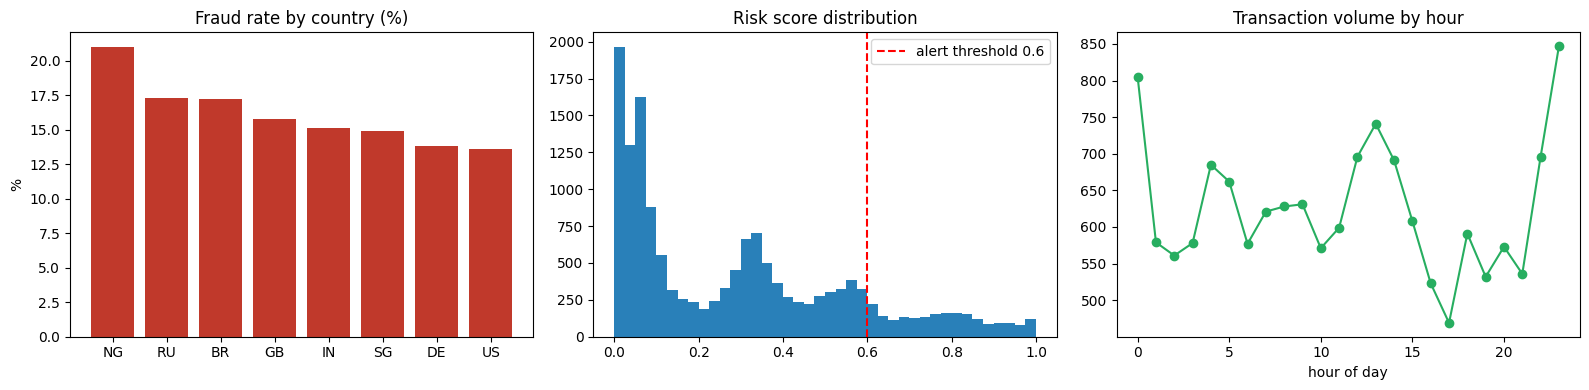

2026-09-18 18:26:30,312 | INFO | Rendered risk dashboard


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. fraud rate by country
by_country = pd.read_sql("""
    SELECT txn_country, ROUND(AVG(is_fraud)*100,1) fraud_pct
    FROM fct_transaction GROUP BY txn_country ORDER BY fraud_pct DESC""", con)
axes[0].bar(by_country["txn_country"], by_country["fraud_pct"], color="#c0392b")
axes[0].set_title("Fraud rate by country (%)"); axes[0].set_ylabel("%")

# 2. risk score distribution
axes[1].hist(feat["risk_score"], bins=40, color="#2980b9")
axes[1].axvline(RISK_THRESHOLD, color="red", linestyle="--", label=f"alert threshold {RISK_THRESHOLD}")
axes[1].set_title("Risk score distribution"); axes[1].legend()

# 3. transaction volume by hour
by_hour = feat.groupby("hour")["transaction_id"].count()
axes[2].plot(by_hour.index, by_hour.values, marker="o", color="#27ae60")
axes[2].set_title("Transaction volume by hour"); axes[2].set_xlabel("hour of day")

plt.tight_layout(); plt.show()
logger.info("Rendered risk dashboard")

In [ ]:
print("=== PIPELINE HEALTH ===")
print(f"Transactions ingested : {pd.read_sql('SELECT COUNT(*) n FROM fct_transaction', con)['n'][0]:,}")
print(f"Customers (dim)        : {pd.read_sql('SELECT COUNT(*) n FROM dim_customer', con)['n'][0]:,}")
print(f"Risk alerts raised     : {pd.read_sql('SELECT COUNT(*) n FROM fct_risk_alerts', con)['n'][0]:,}")
print(f"Model ROC-AUC          : {auc:.3f}")
print("\n=== LAST 15 LOG LINES ===")
print("".join(open('pipeline.log').readlines()[-15:]))

=== PIPELINE HEALTH ===
Transactions ingested : 15,000
Customers (dim)        : 200
Risk alerts raised     : 2,093
Model ROC-AUC          : 0.821

=== LAST 15 LOG LINES ===
2026-09-18 18:26:07,988 | INFO |   validation [PASS] amount positive
2026-09-18 18:26:07,995 | INFO |   validation [PASS] status in {success,failed}
2026-09-18 18:26:08,408 | INFO | Loaded raw tables into SQLite warehouse
2026-09-18 18:26:08,448 | INFO | Built dbt-pattern layers: staging + intermediate
2026-09-18 18:26:08,634 | INFO | dbt test [PASS] unique  stg_transactions.transaction_id
2026-09-18 18:26:08,638 | INFO | dbt test [PASS] not_null stg_transactions.amount
2026-09-18 18:26:08,641 | INFO | dbt test [PASS] relationship txn.customer_id -> customer
2026-09-18 18:26:08,901 | INFO | Star schema built (3 dims + 1 fact)
2026-09-18 18:26:11,140 | INFO | Engineered features for 15000 transactions
2026-09-18 18:26:18,396 | INFO | Model trained | ROC-AUC=0.821
2026-09-18 18:26:19,616 | INFO | Wrote 2093 risk alert

---
## Ask your own questions

In [ ]:
# Try your own — e.g. "which channel has the highest average transaction amount?"
answer_question("Which merchant category has the highest total transaction value?")

2026-09-18 18:26:30,346 | INFO | NL query: Which merchant category has the highest total transaction value?


Generated SQL:
 SELECT
  T2.category
FROM fct_transaction AS T1
INNER JOIN dim_merchant AS T2
  ON T1.merchant_id = T2.merchant_id
GROUP BY
  T2.category
ORDER BY
  SUM(T1.amount) DESC
LIMIT 1; 

   category
electronics 

Explanation: The "electronics" merchant category has the highest total transaction value. This indicates that consumers are spending the most money on electronic goods compared to other categories. This insight is valuable for businesses in the electronics sector as it highlights a strong demand and suggests potential areas for investment and marketing focus.


,category
0,electronics
